In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
import scipy.stats as stats
from scipy.optimize import least_squares
import statsmodels.stats.diagnostic as smd
import glob
from io import StringIO

In [39]:
def data_wrangling(data_folder):
    all_dfs = []
    files = glob.glob(os.path.join(data_folder, '*.csv'))
    print(f" Found {len(files)} CSV files in {data_folder}\n")

    for file_path in files:
        try:
            # Try reading file with UTF-8, fallback to UTF-8-SIG
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    lines = f.readlines()
            except UnicodeDecodeError:
                with open(file_path, 'r', encoding='utf-8-sig') as f:
                    lines = f.readlines()
            # Skip 2 header lines after first
            if len(lines) < 4:
                print(f" File too short to process: {file_path}")
                continue
            df = pd.read_csv(StringIO(''.join(lines)))
            df = df.dropna(subset=["trlno"]).copy()
            # remove practice trials
            df = df[df['stochasticity'].isin(['low', 'high'])]

            df = df.sort_values(by='trlno').reset_index(drop=True)
            df['blkNo'] = ((df['trlno'] - 16) // 50) + 1  # First 15 trials are practice
            df = df[df['trlno'] > 15]

            df['sub'] = df['participant']
            df["trlNo"] = df["trlno"].astype(int)
            df["stim_duration"] = pd.to_numeric(df["stim_duration"], errors="coerce")
            df["rpr_duration"] = pd.to_numeric(df["rpr_duration"], errors="coerce")
            # calculate error
            df['rep_err'] = df['rpr_duration'] - df['stim_duration']

            df["prev_stochasticity"] = df["stochasticity"].shift(50)
            # add a new column preErr, indicating the previous trial's error
            df['preErr'] = df.groupby(['sub', 'stochasticity'])['rep_err'].shift(1)
            # add a new column preDuration, the duration of the previous visual stimulus
            df['preDuration'] = df.groupby(['sub', 'stochasticity'])['stim_duration'].shift(1)
            block_stoch = df.groupby(['sub', 'blkNo'])['stochasticity'].first().reset_index()
            block_stoch['prev_stochasticity'] = block_stoch.groupby('sub')['stochasticity'].shift(1)
            block_stoch['block_transition'] = block_stoch['prev_stochasticity'].str[0].str.upper().fillna('S') + \
                                  block_stoch['stochasticity'].str[0].str.upper()
            # Merge transition labels back into the main DataFrame
            df = df.merge(block_stoch[['sub', 'blkNo', 'block_transition']], on=['sub', 'blkNo'], how='left')
            # mark outliers that exceed [Duration/3, Duration * 3] or preErr is nan
            df['outlier'] = (df['rpr_duration'] < df['stim_duration']/3) | (df['rpr_duration'] > df['stim_duration']*3) | (rawdata['preErr'].isna())
            # Extract subject ID from file name
            all_dfs.append(df)
        except Exception as e:
            print(f"Failed to process {file_path}: {e}")
    if not all_dfs:
        print("No valid data files processed.")
        return pd.DataFrame()
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"Successfully processed {len(all_dfs)} files.")
    print(f"Unique subjects found: {combined_df['sub'].nunique()}")
    return combined_df

In [40]:
rawdata = data_wrangling(r'C:\Users\ayzac\Desktop\bachelor thesis\vtr1\data')
rawdata.head()

 Found 3 CSV files in C:\Users\ayzac\Desktop\bachelor thesis\vtr1\data

Successfully processed 3 files.
Unique subjects found: 3


,participant,age,gender (M/F),trlno,orientation,stochasticity,stim_duration,rpr_duration,rpr_onset,blkNo,sub,trlNo,rep_err,prev_stochasticity,preErr,preDuration,block_transition,outlier
0,356165,22,M,16.0,138.0,high,0.783,0.800,224.303,1.0,356165,16,0.017,None,NaN,NaN,SH,True
1,356165,22,M,17.0,108.0,high,0.984,1.017,229.086,1.0,356165,17,0.033,None,0.017,0.783,SH,False
2,356165,22,M,18.0,80.0,high,1.134,1.266,233.953,1.0,356165,18,0.132,None,0.033,0.984,SH,False
3,356165,22,M,19.0,47.0,high,0.950,1.016,238.920,1.0,356165,19,0.066,None,0.132,1.134,SH,False
4,356165,22,M,20.0,101.0,high,1.117,1.316,243.803,1.0,356165,20,0.199,None,0.066,0.950,SH,False


The key columns are:
   1. stim_duration: the duration of the visual stimulus
   2. rpr_duration: the reproduced duration
   3. rep_err: the reproduction error (Reproduction - Duration)
   4. preDuration: the duration of the previous visual stimulus
   5. sub: subject ID
   6. stochasticity: Low Vola. or High Vola.
   7. block_transition: either low -> high, low -> low, high -> low or high -> high

Outlier percentage grouped by participant:

In [27]:
rawdata.groupby(['sub'])['outlier'].mean().reset_index().groupby('sub')['outlier'].mean()

sub
356165    0.03
843590    0.01
qcy       0.03
Name: outlier, dtype: float64

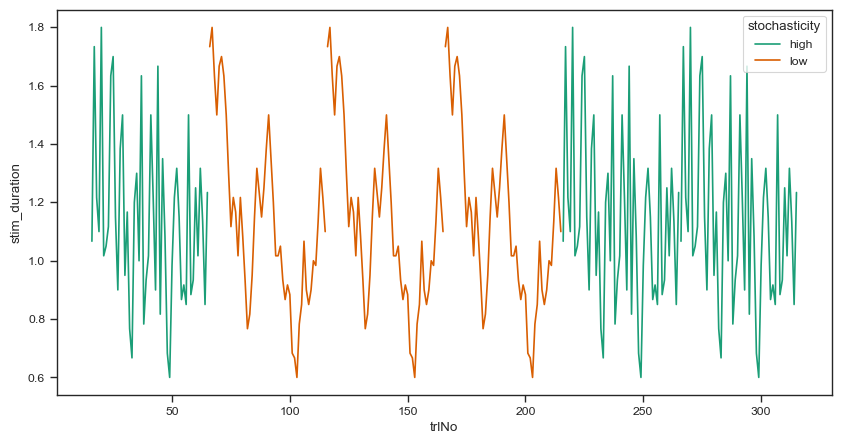

In [52]:
# sns
sns.set_theme(style='ticks', context='paper', rc={'figure.figsize': (10, 5)})
#sns.color_palette(palette='colorblind')
palette = sns.color_palette("Dark2")

# select a subset of rawdata (sub == 'ara27') for illustration
subdata = rawdata.query('sub == "qcy"')
# plot Duration as a function of trlNo, using different color for Volatility
# use color palette 'colorblind' from seaborn
#sns.set_palette('colorblind')
added_labels = set()

# Start plot
plt.figure()

# Plot lines by block and stochasticity
for _, block_df in subdata.groupby('blkNo'):
    for stochasticity_level, sub_df in block_df.groupby('stochasticity'):
        color = palette[0] if stochasticity_level == 'high' else palette[1]
        label = stochasticity_level if stochasticity_level not in added_labels else None
        sns.lineplot(
            x='trlNo',
            y='stim_duration',
            data=sub_df.sort_values('trlNo'),
            color=color,
            label=label
        )
        added_labels.add(stochasticity_level)

# Show legend with both labels
plt.legend(title='stochasticity')
plt.show()

In [42]:
mdata = rawdata.query('outlier == False').groupby(['sub', 'stochasticity', 'stim_duration', 'blkNo']).agg(
    {'rep_err': ['mean', 'std']}).reset_index()
mdata.columns = ['sub', 'stochasticity', 'stim_duration', 'blkNo', 'rep_err', 'rep_err_std']

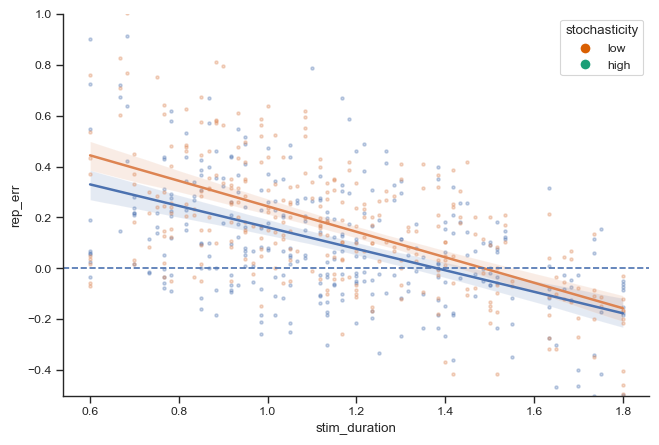

In [47]:
# visualize the mean reproduction error as a function of Duration
ax = sns.lmplot(
    x='stim_duration', y='rep_err', hue='stochasticity', data=mdata, hue_order=['low', 'high'], scatter_kws={'alpha': 0.3, 's': 5}, legend=False, height=4.5,
    aspect=1.5
)

# Add a dashed horizontal line at y=0
for ax1 in ax.axes.flat:
    ax1.axhline(0, ls='--')

# Set y-axis limits
plt.ylim(-0.5, 1.)

# Create a manual legend using seaborn's default color palette
from matplotlib.lines import Line2D
palette = sns.color_palette("Dark2")
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='low', markerfacecolor=palette[1], markersize=8),
    Line2D([0], [0], marker='o', color='w', label='high', markerfacecolor=palette[0], markersize=8)
]
plt.legend(title='stochasticity', handles=legend_elements)

# Show plot
plt.show()

In [53]:
def plot_histograms(df, column='rpr_duration', groupby='sub', bins=30):
    subjects = df[groupby].unique()
    n_cols = 3
    n_rows = int(np.ceil(len(subjects) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, sub in enumerate(subjects):
        sub_data = df[df[groupby] == sub][column]
        axes[i].hist(sub_data.dropna(), bins=bins, color='skyblue', edgecolor='black')
        axes[i].set_title(f'{column} Histogram - {sub}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')

    # Remove unused subplots
    for ax in axes[len(subjects):]:
        fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

#  Function 4 plotting Q-Q plots for each subject
def plot_qqplots(df, column='rpr_duration', groupby='sub'):
    subjects = df[groupby].unique()
    n_cols = 3
    n_rows = int(np.ceil(len(subjects) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    for i, sub in enumerate(subjects):
        sub_data = df[df[groupby] == sub][column].dropna()
        stats.probplot(sub_data, dist="norm", plot=axes[i])
        axes[i].set_title(f'Q-Q Plot - {sub}')
    for ax in axes[len(subjects):]:
        fig.delaxes(ax)
        plt.tight_layout()
    plt.show()

Reproduction distribution grouped by participants, outliers included:

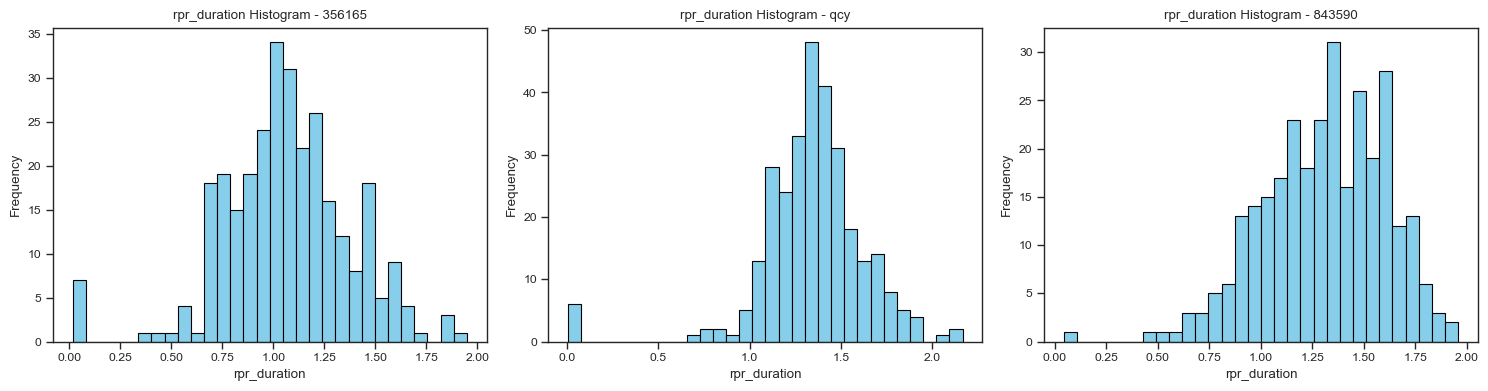

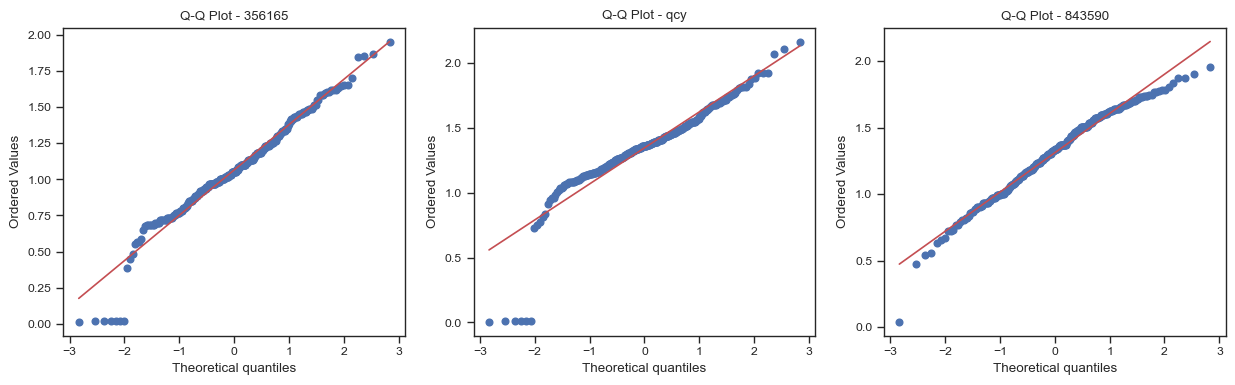

In [54]:
plot_histograms(rawdata)
plot_qqplots(rawdata)

Reproduction distribution grouped by participants, no outliers


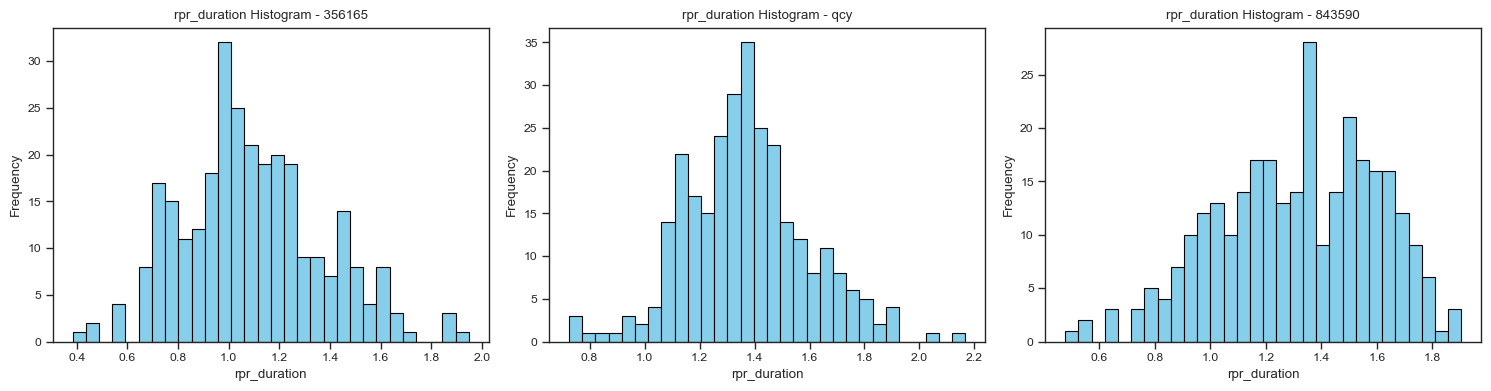

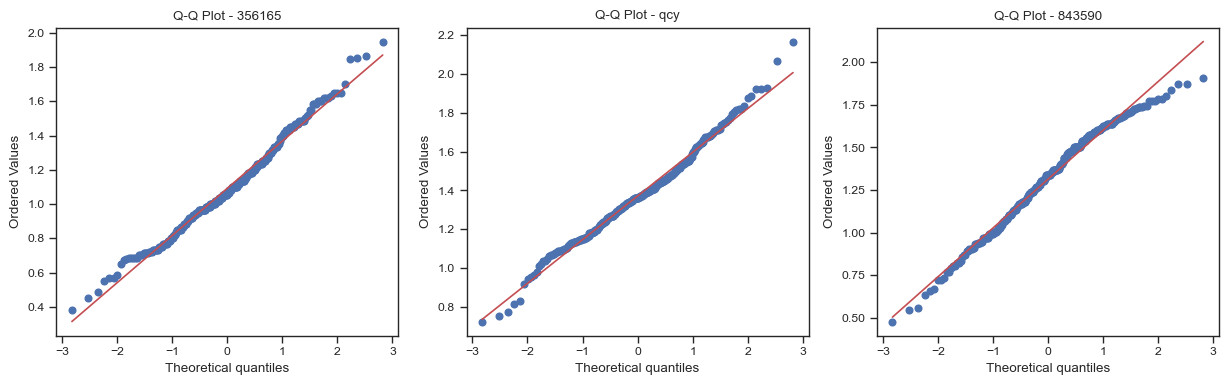

In [55]:
plot_histograms(rawdata.query('outlier == False'))
plot_qqplots(rawdata.query('outlier == False'))

Frequencies of block transitions, excluding the first blocks:

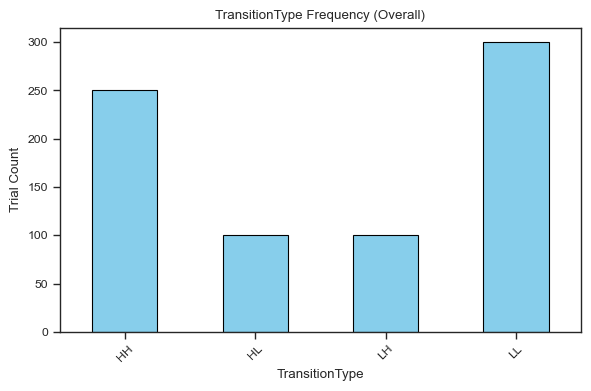

Overall Transition Type Proportions (%):
block_transition
HH    33.33 %
HL    13.33 %
LH    13.33 %
LL     40.0 %
Name: proportion, dtype: object


In [59]:
# TransitionType
transition_counts = rawdata[rawdata['block_transition'].isin(['HH', 'HL', 'LH', 'LL'])]["block_transition"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
transition_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("TransitionType Frequency (Overall)")
plt.xlabel("TransitionType")
plt.ylabel("Trial Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
transition_prop = rawdata[rawdata['block_transition'].isin(['HH', 'HL', 'LH', 'LL'])]["block_transition"].value_counts(normalize=True).sort_index()
print("Overall Transition Type Proportions (%):")
print((transition_prop * 100).round(2).astype(str) + " %")

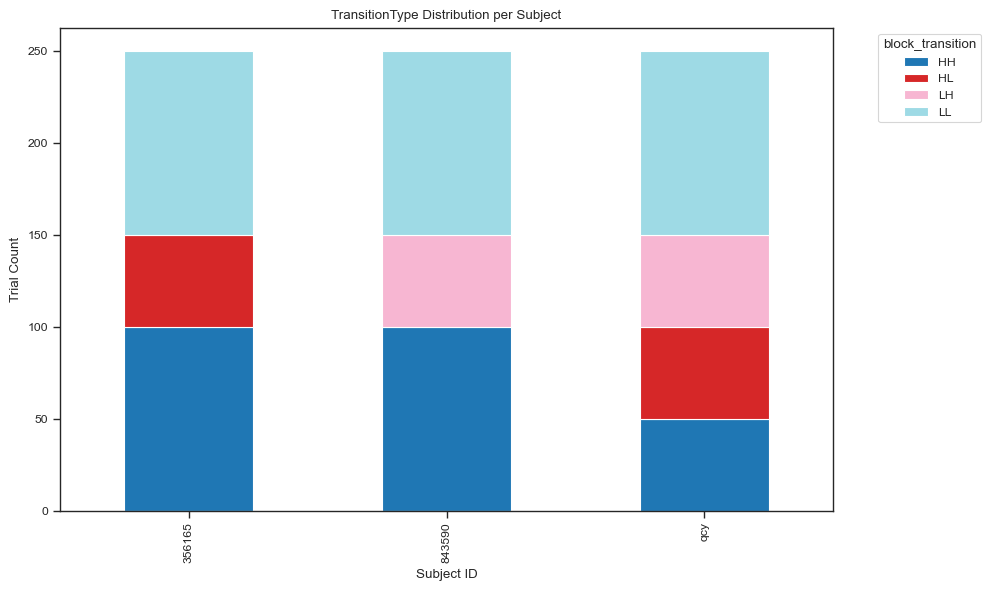

TransitionType proportions per subject (%):
block_transition      HH      HL      LH      LL
sub                                             
356165            40.0 %  20.0 %   0.0 %  40.0 %
843590            40.0 %   0.0 %  20.0 %  40.0 %
qcy               20.0 %  20.0 %  20.0 %  40.0 %


In [61]:
transition_by_subject = rawdata[rawdata['block_transition'].isin(['HH', 'HL', 'LH', 'LL'])].pivot_table( index="sub", columns="block_transition", aggfunc="size", fill_value=0)
transition_by_subject.plot( kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title("TransitionType Distribution per Subject")
plt.xlabel("Subject ID")
plt.ylabel("Trial Count")
plt.xticks(rotation=90)
plt.legend(title="block_transition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
transition_by_subject_prop = transition_by_subject.div(transition_by_subject.sum(axis=1), axis=0)
print("TransitionType proportions per subject (%):")
print((transition_by_subject_prop * 100).round(2).astype(str) + " %")

As can be seen, not all participants are subjected to all transition types, nor do they all have the same frequency, because of the randomness of the block order.